# Campaña de Marketing Bancario
## Comprensión empresarial

Los depósitos a largo plazo permiten a los bancos retener dinero durante un período de tiempo específico, lo que permite al banco utilizar ese dinero para mejorar sus inversiones. Las campañas de marketing de este producto se basan en llamadas telefónicas. Si un usuario no se encuentra disponible en un momento dado, entonces se le volverá a llamar de nuevo en otro momento.

## Descripción del problema

El banco portugués está teniendo una disminución en sus ingresos, por lo que quieren poder identificar a los clientes existentes que tienen una mayor probabilidad de contratar un depósito a largo plazo. Esto permitirá que el banco centre sus esfuerzos de marketing en esos clientes y evitará perder dinero y tiempo en clientes que probablemente no se suscribirán.

Para abordar este problema crearemos un algoritmo de clasificación que ayude a predecir si un cliente contratará o no un depósito a largo plazo.

### Exploratory data analysis

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

In [3]:
#Import and create dataframe
df = pd.read_csv('/workspaces/crerov-intro-machine-learning/data/raw/bank-marketing-campaign-data.csv', sep=';')
df

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes


In [4]:
df.shape


(41188, 21)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

No hay valores nulos

In [6]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'],
      dtype='str')

In [7]:
cat_columns = df.select_dtypes(include=['object', 'string']).columns

for col in cat_columns:
    valores = df[col].unique()
    print(f"-> {col.upper()}: {list(valores)}")

-> JOB: ['housemaid', 'services', 'admin.', 'blue-collar', 'technician', 'retired', 'management', 'unemployed', 'self-employed', 'unknown', 'entrepreneur', 'student']
-> MARITAL: ['married', 'single', 'divorced', 'unknown']
-> EDUCATION: ['basic.4y', 'high.school', 'basic.6y', 'basic.9y', 'professional.course', 'unknown', 'university.degree', 'illiterate']
-> DEFAULT: ['no', 'unknown', 'yes']
-> HOUSING: ['no', 'yes', 'unknown']
-> LOAN: ['no', 'yes', 'unknown']
-> CONTACT: ['telephone', 'cellular']
-> MONTH: ['may', 'jun', 'jul', 'aug', 'oct', 'nov', 'dec', 'mar', 'apr', 'sep']
-> DAY_OF_WEEK: ['mon', 'tue', 'wed', 'thu', 'fri']
-> POUTCOME: ['nonexistent', 'failure', 'success']
-> Y: ['no', 'yes']


#### Variable Descriptions

#### Client Data (Profile)
**age**: Age of the client (numeric).

**job**: Type of job (categorical: 'admin.', 'blue-collar', 'entrepreneur', etc.).

**marital**: Marital status ('married', 'single', 'divorced').

**education**: Education level ('basic.4y', 'high.school', 'university.degree', etc.).

**default**: Has credit in default? ('no', 'yes', 'unknown').

**housing**: Has housing loan? ('no', 'yes', 'unknown').

**loan**: Has personal loan? ('no', 'yes', 'unknown').

#### Contact Data (Current Campaign)

**contact**: Contact communication type ('cellular', 'telephone').

**month**: Last contact month of year ('may', 'jun', etc.).

**day_of_week**: Last contact day of the week.

**duration**: Last contact duration in seconds. Important: If it is 0, y will be 'no'.

**campaign**: Number of contacts performed during this campaign and for this client.

#### Historical Data (Past Campaigns)
**pdays**: Number of days that passed by after the client was last contacted from a previous campaign (999 means client was not previously contacted).

**previous**: Number of contacts performed before this campaign and for this client.

**poutcome**: Outcome of the previous marketing campaign ('failure', 'nonexistent', 'success').

#### Economic Indicators (Social Context)
**emp.var.rate**: Employment variation rate (quarterly indicator).

**cons.price.idx**: Consumer price index (monthly indicator).

**cons.conf.idx**: Consumer confidence index (monthly indicator).

**euribor3m**: Euribor 3 month rate (daily indicator).

**nr.employed**: Number of employees in the economy (quarterly indicator).

#### Target Variable (What we want to predict)
**y**: Has the client subscribed a term deposit? ('yes', 'no').

### General information

In [8]:
for col in df.columns:
    count = (df[col] == 'unknown').sum()
    if count > 0:
        print(f"{col}: {count} valores 'unknown'")

job: 330 valores 'unknown'
marital: 80 valores 'unknown'
education: 1731 valores 'unknown'
default: 8597 valores 'unknown'
housing: 990 valores 'unknown'
loan: 990 valores 'unknown'


We should consider what the "unknown" means for our analysis. For example, do people with "unknown" education have a higher or lower success rate than average? Sometimes, "not knowing" is a useful signal.

In [9]:
# Checking some columns
df["default"].value_counts()

default
no         32588
unknown     8597
yes            3
Name: count, dtype: int64

The default column has too many missing or unknown values (around 20% of the dataset), so it was removed as it provides little meaningful information for the analysis.

In [10]:
# Dropping irrelevant information
df.drop(["default"], axis = 1, inplace = True)
df

,age,job,marital,education,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,yes,no,cellular,nov,fri,334,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,cellular,nov,fri,383,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,yes,no,cellular,nov,fri,189,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,cellular,nov,fri,442,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes


## Visualization

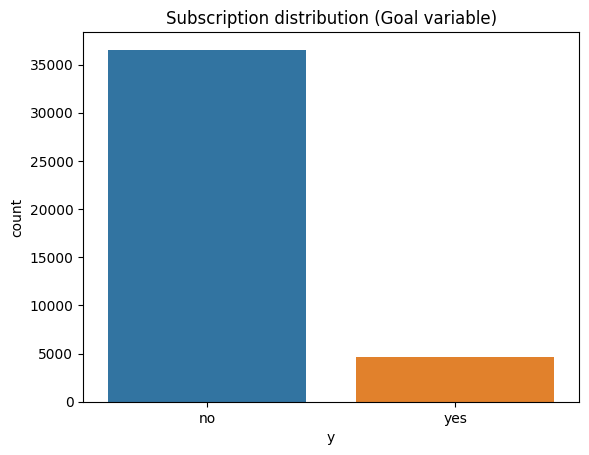

y
no     88.734583
yes    11.265417
Name: proportion, dtype: float64


In [11]:
sns.countplot(x='y', data=df, hue = 'y')
plt.title('Subscription distribution (Goal variable)')
plt.show()

print(df['y'].value_counts(normalize=True) * 100)

Goal variable is not balanced

In [12]:
# Factorize for categorical features
df_factorized = df.copy()
df_factorized["job_n"] = pd.factorize(df_factorized["job"])[0]
df_factorized["marital_n"] = pd.factorize(df_factorized["marital"])[0]
df_factorized["education_n"] = pd.factorize(df_factorized["education"])[0]
df_factorized["housing_n"] = pd.factorize(df_factorized["housing"])[0]
df_factorized["loan_n"] = pd.factorize(df_factorized["loan"])[0]
df_factorized["contact_n"] = pd.factorize(df_factorized["contact"])[0]
df_factorized["month_n"] = pd.factorize(df_factorized["month"])[0]
df_factorized["day_of_week_n"] = pd.factorize(df_factorized["day_of_week"])[0]
df_factorized["poutcome_n"] = pd.factorize(df_factorized["poutcome"])[0]
df_factorized["y_n"] = pd.factorize(df_factorized["y"])[0]
df_factorized.head()

,age,job,marital,education,housing,loan,contact,month,day_of_week,duration,...,job_n,marital_n,education_n,housing_n,loan_n,contact_n,month_n,day_of_week_n,poutcome_n,y_n
0,56,housemaid,married,basic.4y,no,no,telephone,may,mon,261,...,0,0,0,0,0,0,0,0,0,0
1,57,services,married,high.school,no,no,telephone,may,mon,149,...,1,0,1,0,0,0,0,0,0,0
2,37,services,married,high.school,yes,no,telephone,may,mon,226,...,1,0,1,1,0,0,0,0,0,0
3,40,admin.,married,basic.6y,no,no,telephone,may,mon,151,...,2,0,2,0,0,0,0,0,0,0
4,56,services,married,high.school,no,yes,telephone,may,mon,307,...,1,0,1,0,1,0,0,0,0,0


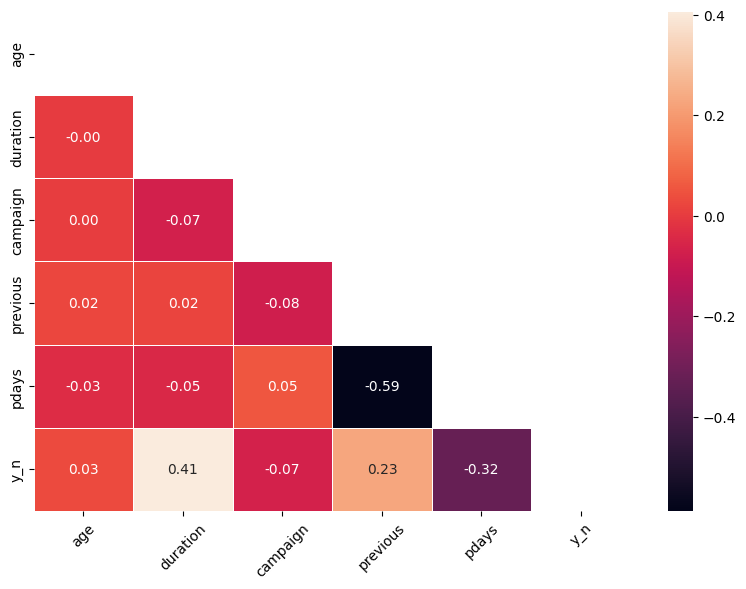

In [13]:
# Client-related numerical features
client_numerical_columns = ["age", "duration", "campaign", "previous", "pdays", "y_n"]
corr_client_numerical = df_factorized[client_numerical_columns].corr()
mask_client_numerical = np.triu(np.ones_like(corr_client_numerical, dtype = bool))

fig, axis = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_client_numerical, mask = mask_client_numerical, annot = True, linewidths = 0.5, fmt = ".2f")
plt.xticks(rotation = 45)

plt.tight_layout()
plt.show()

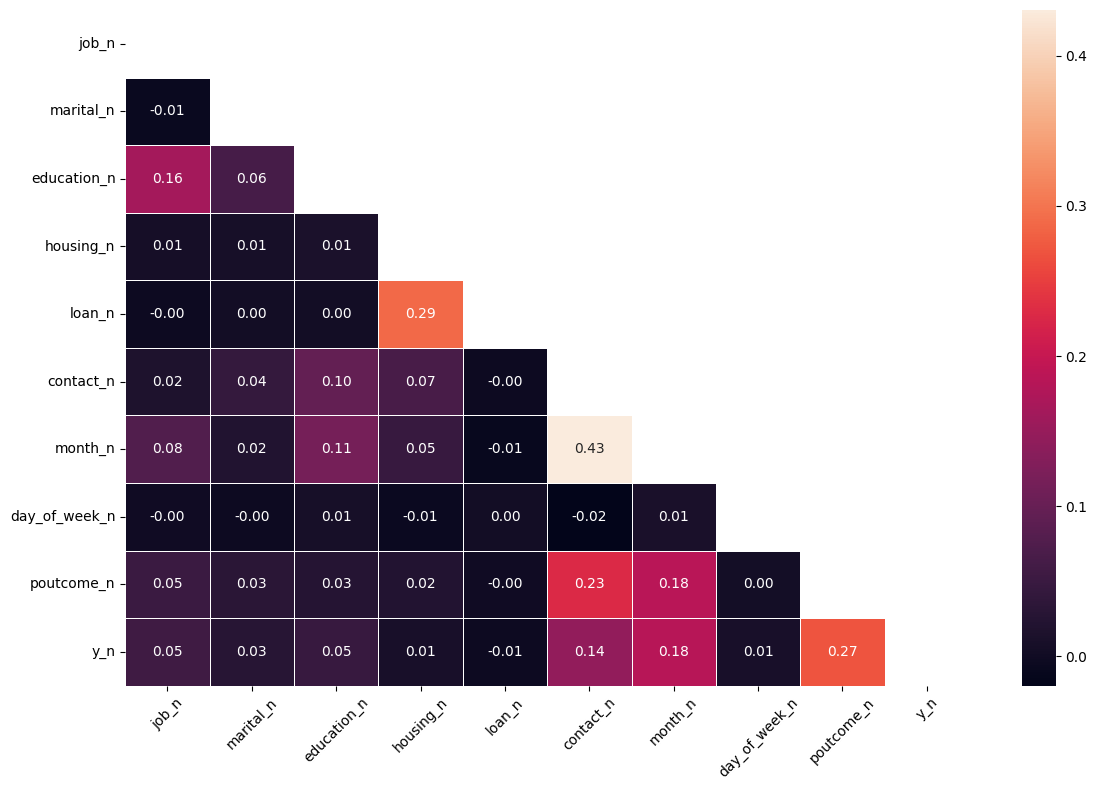

In [14]:
# Client-related categorical features
client_categorical_columns = ["job_n", "marital_n", "education_n", "housing_n", "loan_n", "contact_n", "month_n", "day_of_week_n", "poutcome_n", "y_n"]
corr_client_categorical = df_factorized[client_categorical_columns].corr()
mask_client_categorical = np.triu(np.ones_like(corr_client_categorical, dtype = bool))

fig, axis = plt.subplots(figsize=(12, 8))
sns.heatmap(corr_client_categorical, mask = mask_client_categorical, annot = True, linewidths = 0.5, fmt = ".2f")
plt.xticks(rotation = 45)

plt.tight_layout()
plt.show()

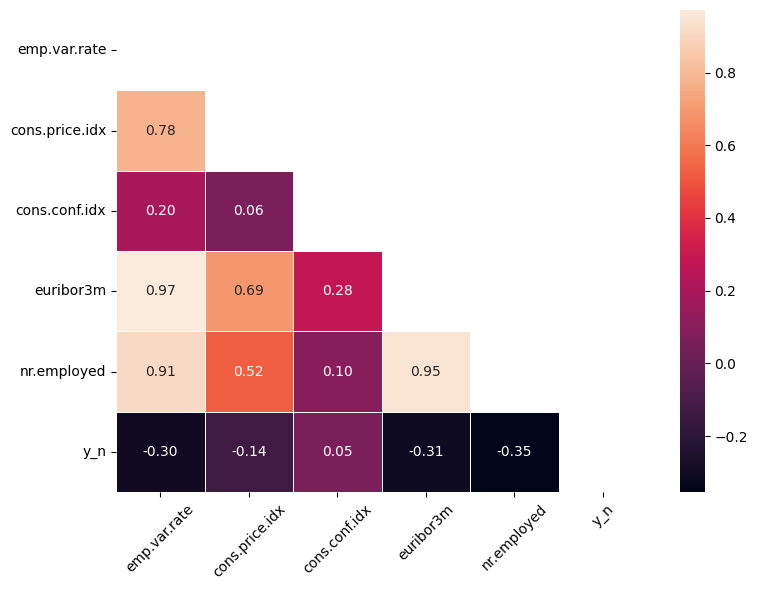

In [15]:
# Bank-related categorical features
bank_columns = ["emp.var.rate", "cons.price.idx", "cons.conf.idx", "euribor3m", "nr.employed", "y_n"]
corr_bank = df_factorized[bank_columns].corr()
mask_bank = np.triu(np.ones_like(corr_bank, dtype = bool))

fig, axis = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_bank, mask = mask_bank, annot = True, linewidths = 0.5, fmt = ".2f")
plt.xticks(rotation = 45)

plt.tight_layout()
plt.show()

### Observations
In the first heatmap, the strongest correlation observed is between the columns pdays (number of days that passed since the last campaign until the client was contacted) and previous (number of contacts performed during the previous campaign to the client), with a value of -0.59. Since both variables describe similar information about the client’s contact history, so I will remove the pdays column and keep previous for our analysis.

In the second heatmap, all correlations between variables, including the target, are very close to 0. The most distant one is 0.43, between month_n (the last month in which the client was contacted) and contact_n (the type of communication used for contact). Since contact_n only contains two similar categories ("cellular" and "telephone") and provides little predictive value, I will remove the contact_n column and keep month_n, which could still capture seasonal effects in client behavior.

In the third heatmap, I see higher correlations between variables. The column emp.var.rate (employment variation rate – quarterly indicator) has a correlation of 0.78 with cons.price.idx (consumer price index – monthly indicator), 0.97 with euribor3m (EURIBOR 3-month rate – daily indicator), and 0.91 with nr.employed (number of employees – quarterly indicator). The column cons.conf.idx (consumer confidence index) also shows a correlation of 0.69 with euribor3m, and euribor3m has a correlation of 0.95 with nr.employed. Since these variables are highly correlated and represent similar macroeconomic information, I will keep only emp.var.rate and cons.conf.idx, and remove euribor3m, nr.employed, and cons.price.idx to avoid redundancy and multicollinearity in the model.

In [16]:
# Dropping irrelevant columns from our original dataframe
df.drop(["pdays", "contact", "euribor3m", "nr.employed", "cons.price.idx"], axis = 1, inplace = True)
df

,age,job,marital,education,housing,loan,month,day_of_week,duration,campaign,previous,poutcome,emp.var.rate,cons.conf.idx,y
0,56,housemaid,married,basic.4y,no,no,may,mon,261,1,0,nonexistent,1.1,-36.4,no
1,57,services,married,high.school,no,no,may,mon,149,1,0,nonexistent,1.1,-36.4,no
2,37,services,married,high.school,yes,no,may,mon,226,1,0,nonexistent,1.1,-36.4,no
3,40,admin.,married,basic.6y,no,no,may,mon,151,1,0,nonexistent,1.1,-36.4,no
4,56,services,married,high.school,no,yes,may,mon,307,1,0,nonexistent,1.1,-36.4,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,yes,no,nov,fri,334,1,0,nonexistent,-1.1,-50.8,yes
41184,46,blue-collar,married,professional.course,no,no,nov,fri,383,1,0,nonexistent,-1.1,-50.8,no
41185,56,retired,married,university.degree,yes,no,nov,fri,189,2,0,nonexistent,-1.1,-50.8,no
41186,44,technician,married,professional.course,no,no,nov,fri,442,1,0,nonexistent,-1.1,-50.8,yes


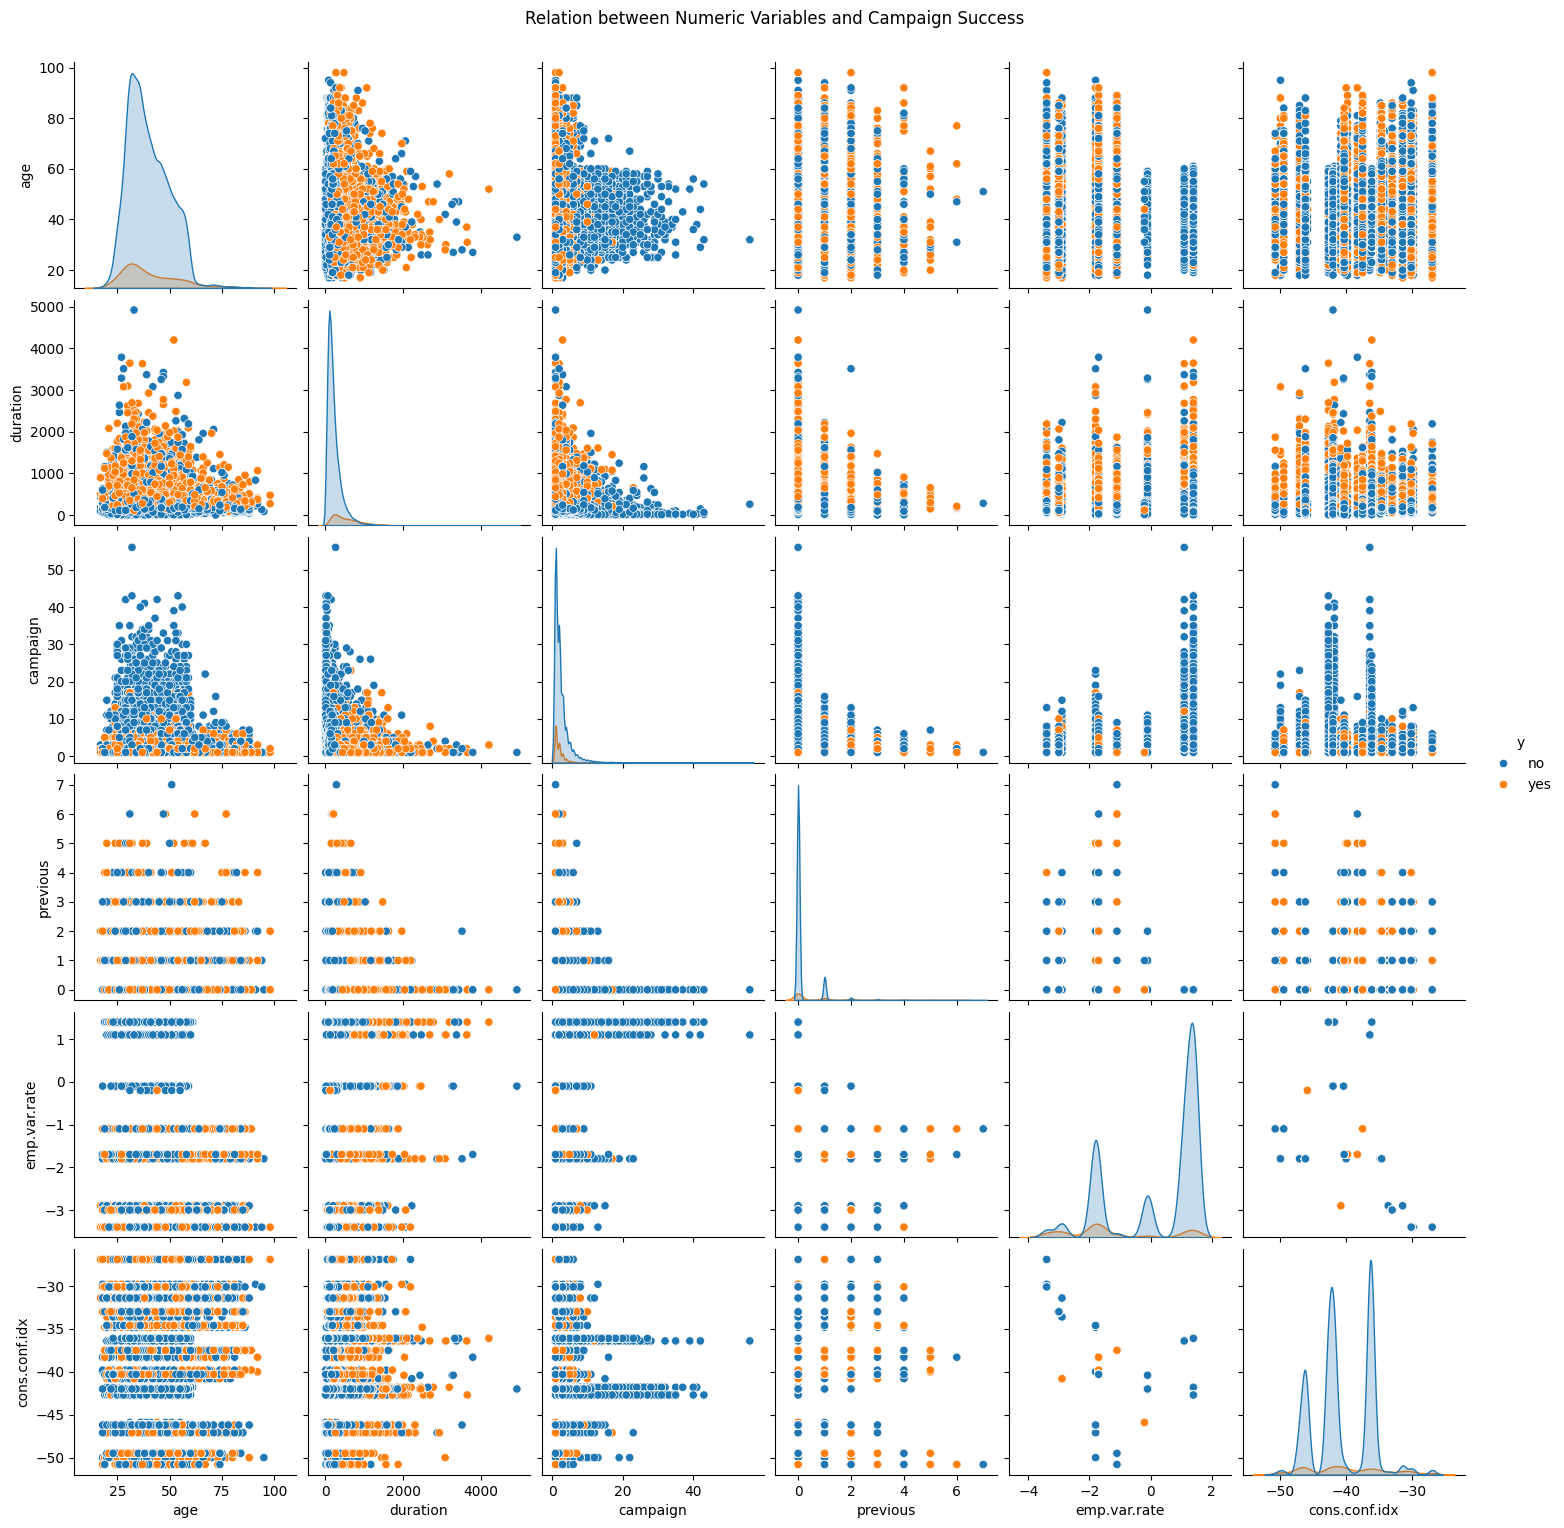

In [17]:
# 1. Pick numeric variables + goal variable 'y'
numeric_var = ['age', 'duration', 'campaign', 'previous', 'emp.var.rate', 'cons.conf.idx', 'y']

# 2. Create pairplot

sns.pairplot(df[numeric_var], hue='y', diag_kind='kde')

plt.suptitle('Relation between Numeric Variables and Campaign Success', y=1.02)
plt.show()

### Analysis of Categorical variables

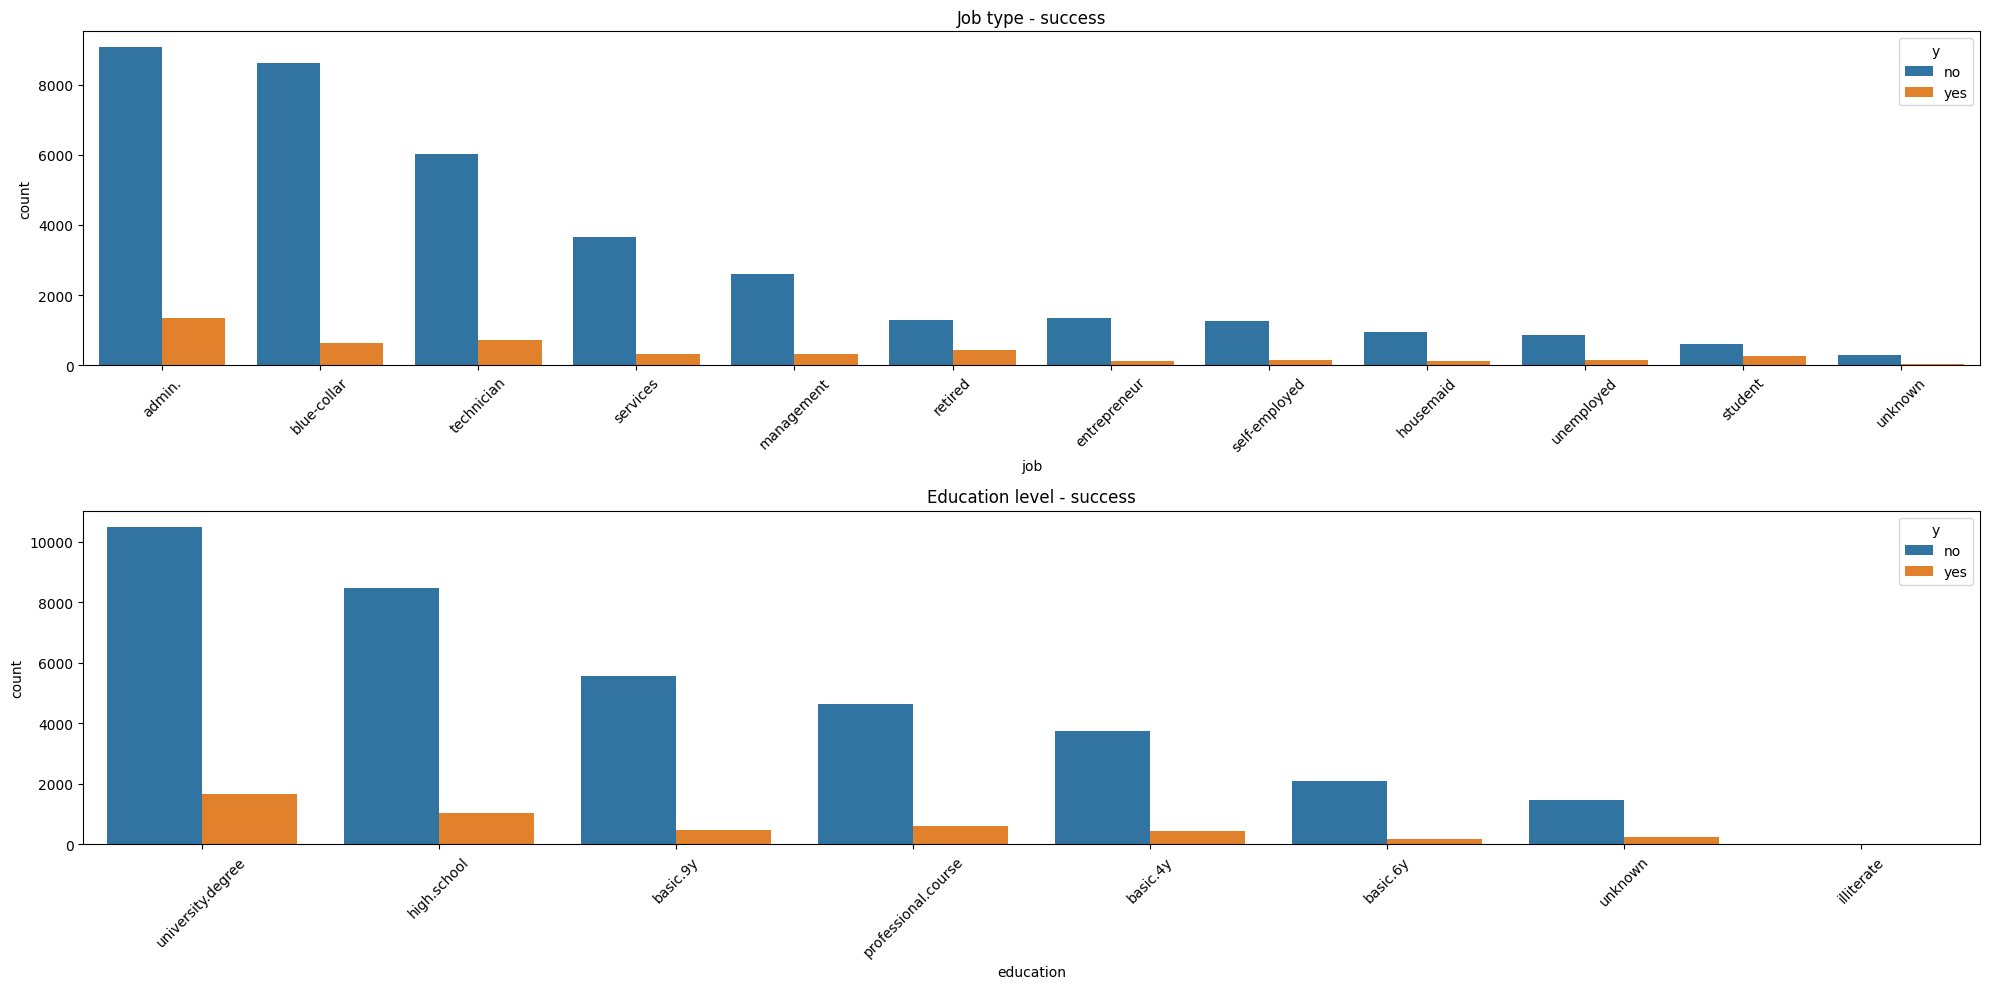

In [18]:
#looking for correlation between job type or education level with campaign success
plt.figure(figsize=(20, 10))

# Job plot
plt.subplot(2, 1, 1)
sns.countplot(data=df, x='job', hue='y', order=df['job'].value_counts().index)
plt.title('Job type - success')
plt.xticks(rotation=45)

# Education Plot
plt.subplot(2, 1, 2)
sns.countplot(data=df, x='education', hue='y', order=df['education'].value_counts().index)
plt.title('Education level - success')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [19]:
# grouping al basic ed since it´s too fragmented
df['education'] = df['education'].replace(['basic.4y', 'basic.6y', 'basic.9y'], 'basic')


#  Check new education plot
print("New education levels:")
print(df['education'].unique())

New education levels:
<StringArray>
[              'basic',         'high.school', 'professional.course',
             'unknown',   'university.degree',          'illiterate']
Length: 6, dtype: str


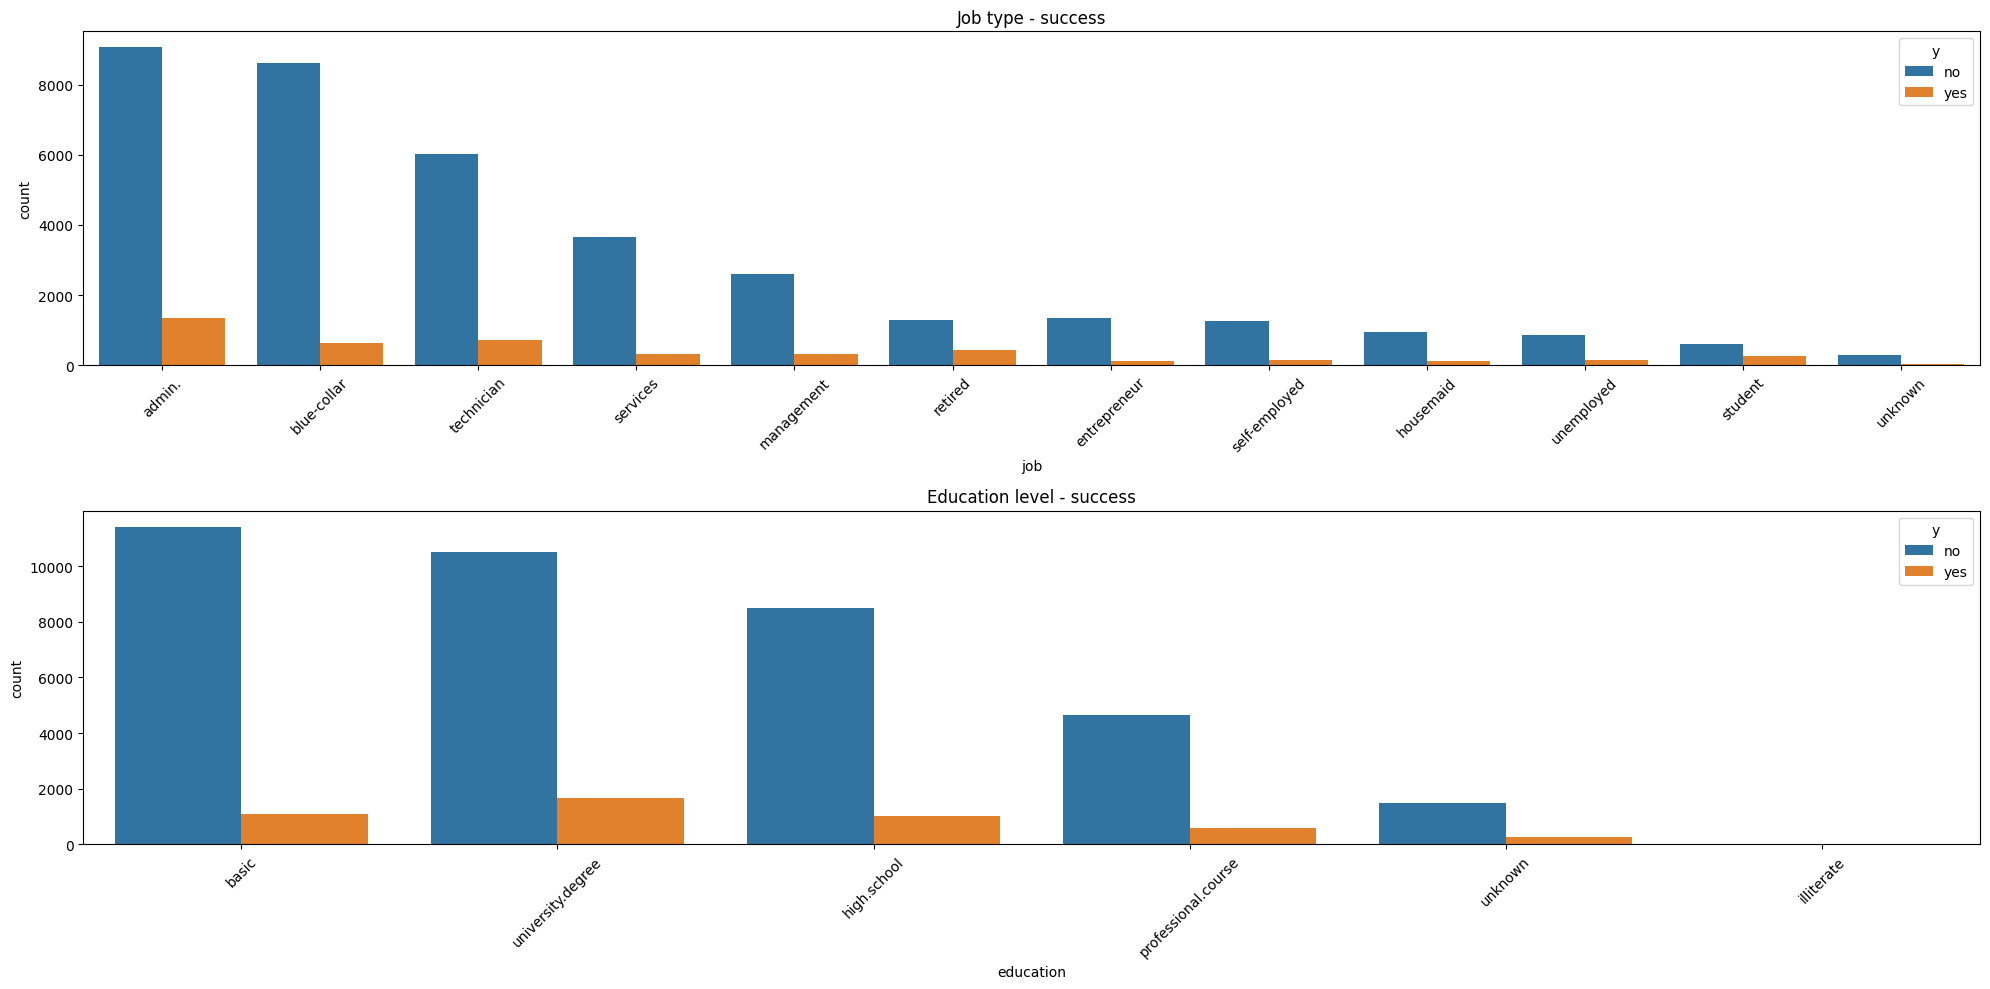

In [20]:
#looking for correlation between job type or education level with campaign success
plt.figure(figsize=(20, 10))

# Job plot
plt.subplot(2, 1, 1)
sns.countplot(data=df, x='job', hue='y', order=df['job'].value_counts().index)
plt.title('Job type - success')
plt.xticks(rotation=45)

# Education Plot
plt.subplot(2, 1, 2)
sns.countplot(data=df, x='education', hue='y', order=df['education'].value_counts().index)
plt.title('Education level - success')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [21]:
#Finding relevance of unknown values
# 1. How many people said yes, by education level
edu_conversion = df.groupby('education')['y'].value_counts(normalize=True).unstack() * 100

# 2. Rename columns for clarity
edu_conversion.columns = ['% No', '% Yes (Conversion)']

# 3. Sorting values for clarity
edu_conversion = edu_conversion.sort_values(by='% Yes (Conversion)', ascending=False)

# 4. Show result
print("Success rate by education level:")
print(edu_conversion)

# 5. Calculate the dataset mean
general_mean = (df['y'] == 'yes').mean() * 100
print(f"\nGeneral success mean: {general_mean:.2f}%")

Success rate by education level:
                          % No  % Yes (Conversion)
education                                         
illiterate           77.777778           22.222222
unknown              85.499711           14.500289
university.degree    86.275477           13.724523
professional.course  88.651535           11.348465
high.school          89.164477           10.835523
basic                91.297051            8.702949

General success mean: 11.27%


Retired people and university-degree people are the most prone to subscribing to a campaign. However, unknown education level people have the highest conversion rate

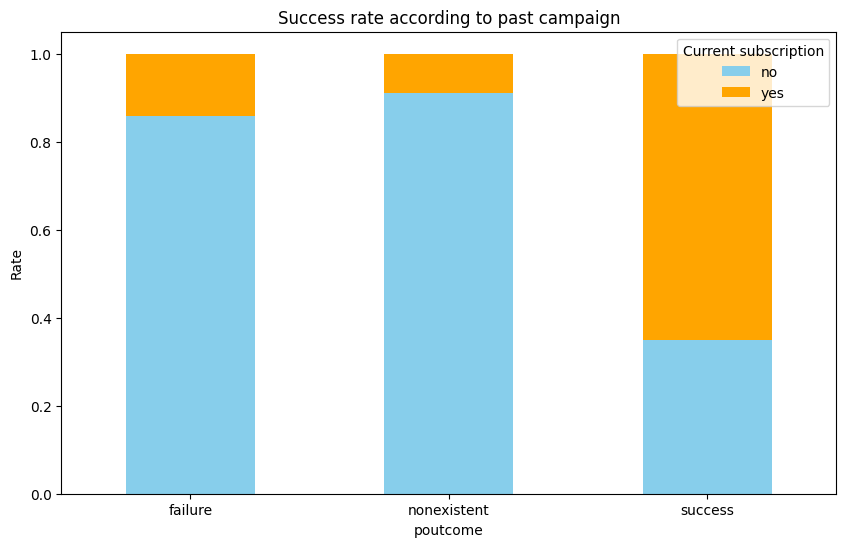

In [22]:
#Look for past success and see it it affects current campaign

poutcome_rel = pd.crosstab(df['poutcome'], df['y'], normalize='index')


poutcome_rel.plot(kind='bar', stacked=True, figsize=(10, 6), color=['skyblue', 'orange'])
plt.title('Success rate according to past campaign')
plt.ylabel('Rate')
plt.xlabel('poutcome')
plt.legend(title='Current subscription', loc='upper right')
plt.xticks(rotation=0)
plt.show()

Surprisingly, a previous failure doesn't necessarily mean a definite "no" now. The success rate is slightly higher than the overall average (~11.27%).

If the client has already said "yes" once, there's more than a 60% chance they'll say yes again. It's an extremely strong predictor.

The hardest part is convincing someone from scratch.

## Train/test split

In [24]:
# Define X (features) and y (target)
X = df.drop(columns = ["y"])
y = df["y"]

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

## Label encoding

In [25]:
# Create copies of the training and test sets
X_train_encoded = X_train.copy()
X_test_encoded = X_test.copy()

# Label Encoder (for ordinal features)
label_encoder = LabelEncoder()
label_encoder.fit(X_train["education"])

X_train_encoded["education_le"] = label_encoder.transform(X_train["education"])
X_test_encoded["education_le"] = label_encoder.transform(X_test["education"])

## One Hot Encoding

In [26]:
categorical_nominal = ["job", "marital", "housing", "loan", "day_of_week", "month", "poutcome"]

onehot_encoder = OneHotEncoder(sparse_output=False, drop="first")
onehot_encoder.fit(X_train[categorical_nominal])

X_train_cat_ohe = onehot_encoder.transform(X_train[categorical_nominal])
X_test_cat_ohe = onehot_encoder.transform(X_test[categorical_nominal])

# Back to dataframe
X_train_ohe_df = pd.DataFrame(X_train_cat_ohe, index=X_train.index, columns=onehot_encoder.get_feature_names_out(categorical_nominal))
X_test_ohe_df = pd.DataFrame(X_test_cat_ohe, index=X_test.index, columns=onehot_encoder.get_feature_names_out(categorical_nominal))

In [27]:
# Dropping original columns
X_train_encoded = X_train_encoded.drop(columns=categorical_nominal + ["education"])
X_test_encoded = X_test_encoded.drop(columns=categorical_nominal + ["education"])

# Setting all together
X_train_final = pd.concat([X_train_encoded, X_train_ohe_df], axis=1)
X_test_final = pd.concat([X_test_encoded, X_test_ohe_df], axis=1)

## Feature Scaling

In [28]:
# Select only numeric columns + encoded columns
columns_to_scale = ["age", "duration", "campaign", "previous", "emp.var.rate", "cons.conf.idx"] + [column for column in X_train_final.columns if column.endswith("_le")]

# Standard Scaler
scaler = StandardScaler()
scaler.fit(X_train_final[columns_to_scale])
X_train_scaled = scaler.transform(X_train_final[columns_to_scale])
X_test_scaled  = scaler.transform(X_test_final[columns_to_scale])

# Convert to DataFrame
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=columns_to_scale)
X_test_scaled_df  = pd.DataFrame(X_test_scaled, columns=columns_to_scale)

X_train_scaled_df.head()

,age,duration,campaign,previous,emp.var.rate,cons.conf.idx,education_le
0,-0.001669,-0.631114,-0.206242,-0.350902,0.838794,-0.472769,-1.133674
1,-0.864095,-0.546321,0.513676,-0.350902,-1.199440,-1.229916,1.124662
2,1.819007,-0.943306,1.233593,1.677559,-1.199440,-1.229916,-1.133674
3,0.285806,-0.631114,0.873635,-0.350902,0.838794,-0.472769,-1.133674
4,-0.097494,0.332441,-0.206242,-0.350902,0.647709,0.890097,-0.569090


## Logistic Regression

In [29]:
# Create the model
model = LogisticRegression(random_state = 18)

# Train the model
model.fit(X_train_scaled_df, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",18
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [30]:
# Make predictions on the test set
y_pred = model.predict(X_test_scaled_df)
y_pred

array(['no', 'no', 'no', ..., 'no', 'yes', 'no'],
      shape=(8238,), dtype=object)

In [31]:
# Evaluate accuracy
model_accuracy = accuracy_score(y_test, y_pred)
model_accuracy

0.9011896091284293

The logistic regression model achieved 90% accuracy on the test set, showing strong baseline performance.

### Observations

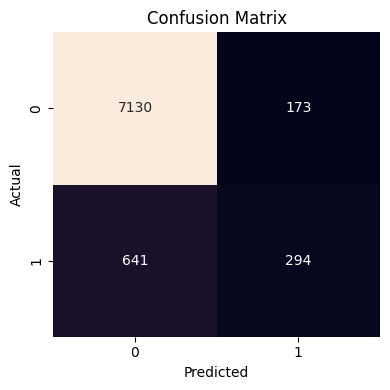

In [32]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
df_cm = pd.DataFrame(cm)

# Chart
plt.figure(figsize = (4, 4))
sns.heatmap(df_cm, annot = True, fmt = "d", cbar = False)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.tight_layout()
plt.show()

##### Cell interpretation
- True Negative (TN) = 7072 → Correctly predicted “no”
- False Positive (FP) = 193 → Predicted “yes” but actually “no”
- False Negative (FN) = 623 → Predicted “no” but actually “yes”
- True Positive (TP) = 348 → Correctly predicted “yes”

#### Results
- The model predicts “no” very well (high TN).
- The model struggles with “yes” (FN > TP).
- The dataset is imbalanced (more “no” than “yes”).
- The high accuracy (0.90) is largely due to the model correctly predicting the majority class ("no"), and does not fully reflect its performance on the minority class ("yes").